In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
size = 50
J = 1

# random grid of spins
spins = np.random.choice([-1, 1], size=(size, size))

In [ ]:
def delta_energy(grid, i, j, J=1):

    size = grid.shape[0]

    spin = grid[i, j]

    # periodic boundary conditions
    neighbors = (
        grid[(i-1) % size, j] +
        grid[(i+1) % size, j] +
        grid[i, (j-1) % size] +
        grid[i, (j+1) % size]
    )

    dE = 2 * J * spin * neighbors

    return dE

In [ ]:
def metropolis_step(grid, T):

    size = grid.shape[0]

    for _ in range(size * size):

        i = np.random.randint(0, size)
        j = np.random.randint(0, size)

        dE = delta_energy(grid, i, j)

        if dE < 0:
            grid[i, j] *= -1
        else:
            r = np.random.rand()
            if r < np.exp(-dE / T):
                grid[i, j] *= -1

    return grid

In [ ]:
temperatures = [0.5, 1.0, 2.0, 2.5, 4.0]
final_grids = []

steps = 5000

for T in temperatures:

    grid = np.random.choice([-1, 1], size=(size, size))

    for step in range(steps):
        grid = metropolis_step(grid, T)

    final_grids.append(grid.copy())

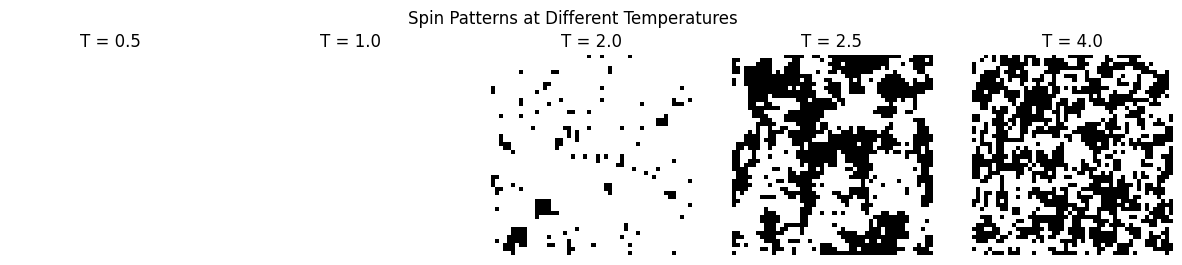

In [ ]:
plt.figure(figsize=(15,3))

for i, grid in enumerate(final_grids):

    plt.subplot(1,5,i+1)
    plt.imshow(grid, cmap='binary')
    plt.title(f"T = {temperatures[i]}")
    plt.axis('off')

plt.suptitle("Spin Patterns at Different Temperatures")
plt.show()

In [ ]:
T = 0.5
grid = np.random.choice([-1,1], size=(size,size))

snapshots = {}
times = [500,1500,3000,5000]

for step in range(1,5001):

    grid = metropolis_step(grid, T)

    if step in times:
        snapshots[step] = grid.copy()

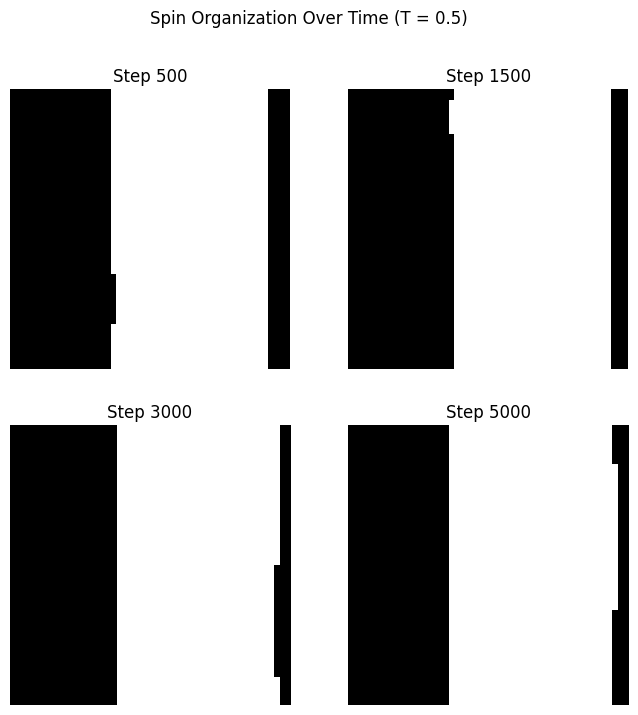

In [ ]:
plt.figure(figsize=(8,8))

for i,t in enumerate(times):

    plt.subplot(2,2,i+1)
    plt.imshow(snapshots[t], cmap='binary')
    plt.title(f"Step {t}")
    plt.axis('off')

plt.suptitle("Spin Organization Over Time (T = 0.5)")
plt.show()

2nd implementation of the Ising model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize the grid
def create_grid(size=50):
    # Returns a 50x50 grid of random +1 and -1
    return np.random.choice([1, -1], size=(size, size))

# Calculate Energy Change (dE)
def get_delta_e(grid, i, j):
    size = grid.shape[0]
    spin_val = grid[i, j]
    # Use modulo (%) to handle wrap-around (periodic boundary conditions)
    neighbors = (grid[(i-1)%size, j] + grid[(i+1)%size, j] +
                 grid[i, (j-1)%size] + grid[i, (j+1)%size])
    # Formula: dE = 2 * J * s_i * sum(neighbors), where J=1
    return 2 * spin_val * neighbors

# The Metropolis Algorithm
def metropolis_step(grid, T):
    size = grid.shape[0]
    # We do size*size attempts to roughly visit every spin once
    for _ in range(size * size):
        i, j = np.random.randint(0, size, size=2)
        dE = get_delta_e(grid, i, j)

        # Acceptance criteria
        if dE <= 0:
            grid[i, j] *= -1 # Accept flip
        elif np.random.rand() < np.exp(-dE / T):
            grid[i, j] *= -1 # Accept flip with probability

# Run Simulation for 5 Temperatures
temperatures = [0.5, 1.0, 2.0, 2.5, 4.0]
final_grids = {}

for T in temperatures:
    grid = create_grid(50)
    for step in range(5000):
        metropolis_step(grid, T)
    final_grids[T] = grid.copy()

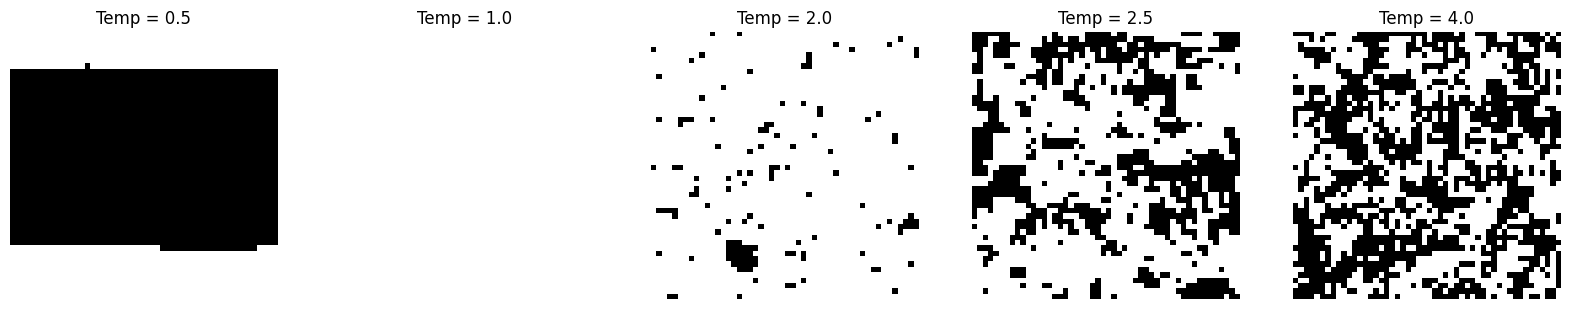

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, T in enumerate(temperatures):
    axes[i].imshow(final_grids[T], cmap='binary')
    axes[i].set_title(f"Temp = {T}")
    axes[i].axis('off')
plt.show()

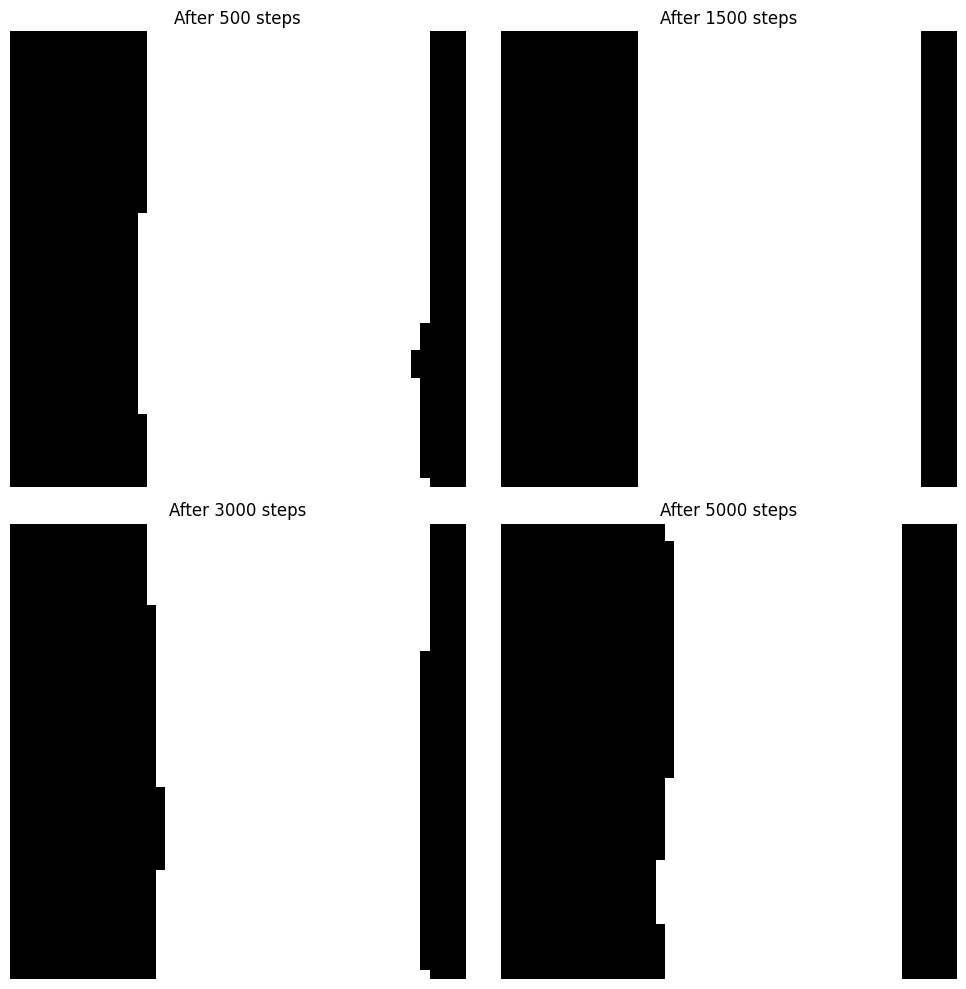

In [ ]:
import matplotlib.pyplot as plt

# Ensure you have initialized grid_evo before this:
grid_evo = create_grid(50)
snapshots = {}
steps_to_save = [500, 1500, 3000, 5000]

# Run the simulation
current_step = 0
for target in steps_to_save:
    # We continue from the last current_step
    while current_step < target:
        metropolis_step(grid_evo, 0.5)
        current_step += 1
    # Save a deep copy of the grid at this moment
    snapshots[target] = grid_evo.copy()

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, step in enumerate(steps_to_save):
    # Use vmin and vmax to ensure binary color mapping is locked correctly
    axes[i].imshow(snapshots[step], cmap='binary', vmin=-1, vmax=1)
    axes[i].set_title(f"After {step} steps")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def calculate_magnetization(grid):
    return np.abs(np.mean(grid))

# Define a range of temperatures
temp_range = np.linspace(0.5, 5.0, 20)
magnetization_results = []

for T in temp_range:
    grid = create_grid(50)
    # Run for enough steps to reach "equilibrium"
    for _ in range(3000):
        metropolis_step(grid, T)

    # Record the final state's magnetization
    mag = calculate_magnetization(grid)
    magnetization_results.append(mag)

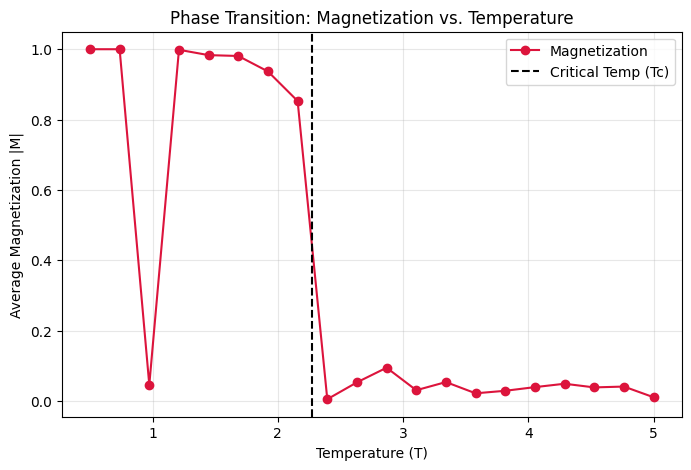

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(temp_range, magnetization_results, 'o-', color='crimson', label='Magnetization')
plt.axvline(x=2.269, color='black', linestyle='--', label='Critical Temp (Tc)')
plt.title("Phase Transition: Magnetization vs. Temperature")
plt.xlabel("Temperature (T)")
plt.ylabel("Average Magnetization |M|")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()